In [1]:
# Import libraries
import requests
import time
import csv

import pandas as pd

In [ ]:
# Removed API_KEY value for security reasons, to run this cell and the rest of the code
# go to https://newsapi.org/register and obtain an api_key and copy, and paste the value below 

# API_KEY = "your_api_key"

URL = "https://newsapi.org/v2/everything"

In [3]:
# Parameters
params = {
    'q': 'technology OR science',     # query for topics
    'language': 'en',
    'sortBy': 'publishedAt',
    'pageSize': 100,   # max per page is 100 for NewsAPI 
    'page': 1,
    'apiKey': API_KEY
}

all_articles = []

while len(all_articles) < 100:
    response = requests.get(URL, params=params)
    data = response.json()
    if data.get('status') != 'ok':
        print("Error from API:", data)
        break

    articles = data.get('articles', [])
    if not articles:
        print("No more articles returned; ending loop.")
        break

    for art in articles:
        # collect at least 3+ attributes per article
        obs = {
            'source': art.get('source', {}).get('name'),
            'author': art.get('author'),
            'title': art.get('title'),
            'description': art.get('description'),
            'url': art.get('url'),
            'publishedAt': art.get('publishedAt'),
            'content': art.get('content')
        }
        all_articles.append(obs)

    print(f"Collected {len(all_articles)} articles so far.")

    # Prepare for next page
    params['page'] += 1

    # Be kind, avoid hitting rate limits
    time.sleep(1)

# Trim in case we fetched a bit over
all_articles = all_articles[:100]


Collected 97 articles so far.
Error from API: {'status': 'error', 'code': 'maximumResultsReached', 'message': 'You have requested too many results. Developer accounts are limited to a max of 100 results. You are trying to request results 100 to 200. Please upgrade to a paid plan if you need more results.'}


In [4]:
# Save dataset to csv file

keys = all_articles[0].keys()
with open('newsapi_articles.csv', 'w', newline='', encoding='utf-8') as f:
    dict_writer = csv.DictWriter(f, keys)
    dict_writer.writeheader()
    dict_writer.writerows(all_articles)

print("Done. Saved to newsapi_articles.csv")

Done. Saved to newsapi_articles.csv


In [5]:
# Save the csv as a pandas dataDrame 
df = pd.read_csv("newsapi_articles.csv")
df.head()

,source,author,title,description,url,publishedAt,content
0,The Star Online,Heejin Kim,"South Korea's new president, injured as a chil...","DANGJIN, South Korea (Reuters) -South Korean K...",https://www.thestar.com.my/news/world/2025/11/...,2025-11-16T23:15:00Z,"DANGJIN, South Korea (Reuters) -South Korean K..."
1,Biztoc.com,fortune.com,The 2026 class of American Rhodes scholars inc...,Five students at U.S. military academies and t...,https://biztoc.com/x/36fdc2f513f1e78b,2025-11-16T23:12:34Z,Five students at U.S. military academies and t...
2,Motley Fool Australia,James Mickleboro,Guess which ASX defence stock is jumping 6% on...,This defence stock just secured a big contract...,https://www.fool.com.au/2025/11/17/guess-which...,2025-11-16T23:07:22Z,Electro Optic Systems Holdings Ltd (ASX: EOS) ...
3,Thesun.my,John Gilbert,Malaysia must be investor-ready for global ren...,Malaysia must be investor-ready for global ren...,https://thesun.my/business/global-business/mal...,2025-11-16T23:06:42Z,KUALA LUMPUR: Having established a firm footin...
4,Just Jared,Just Jared,Is Jalen Hurts Single? He's Newly Married to W...,Sunday Night Football continues tonight (Novem...,https://www.justjared.com/2025/11/16/is-jalen-...,2025-11-16T23:04:21Z,Sunday Night Football continues tonight (Novem...


In [6]:
df['source']

0           The Star Online
1                Biztoc.com
2     Motley Fool Australia
3                 Thesun.my
4                Just Jared
              ...          
92             OilPrice.com
93          Digital Journal
94        Notebookcheck.net
95                 Pypi.org
96                PCMag.com
Name: source, Length: 97, dtype: object

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [8]:
text = ' '.join(df['source'].astype(str))

In [9]:
# Create a WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100, colormap='viridis').generate(text)

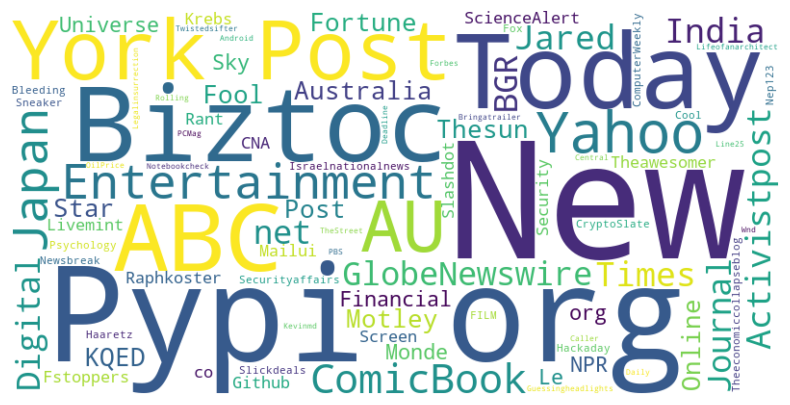

In [10]:
# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Hide the axes
plt.show()